# 👶 SmartBabyScale - Machine Learning Pipeline
### Complete Preprocessing, Training, Validation, and Serialization Workflow

This Jupyter Notebook contains the complete machine learning workflow for training risk classification models for the **SmartBabyScale** system. 

### 🏥 Clinical Context: SNAPPE-II
The **SNAPPE-II** (Score for Neonatal Acute Physiology with Perinatal Extension-II) is a validated clinical scoring system used in Neonatal Intensive Care Units (NICUs) to assess illness severity and predict mortality. The score ranges from **0 to 162**, where higher scores indicate a higher probability of mortality. It comprises:
1. **6 physiological parameters** (representing acute physiology instability collected within 12 hours of admission).
2. **3 perinatal extension parameters** (birth weight, low Apgar score, and Small for Gestational Age status).

### 🤖 Machine Learning Infrastructure Overview
To deploy this model on a **Raspberry Pi** edge device, we train two distinct architectures:
1. **Support Vector Machine (SVM)** with a Radial Basis Function (RBF) kernel: Excellent for establishing non-linear separating boundaries on low-to-medium dimensional tabular data.
2. **Multi-Layer Perceptron (MLP)** Feedforward Neural Network: Learns complex hierarchical feature representations via backpropagation.

Both models are trained to predict the probability of **clinical instability risk (is_unstable)** based on vital signs (sensors) and static demographic inputs.

## 🛠️ Step 1: Import Dependencies & Core Setup
We use standard scientific Python libraries (`numpy`, `pandas`, `matplotlib`) alongside `scikit-learn` for preprocessing, modeling, and evaluation. `joblib` is used to serialize the trained artifacts for edge deployment.

In [1]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Model Preprocessing and Data Splitting
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Classification Models
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

# Diagnostic and Performance Evaluation Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, roc_curve, auc
)

# Set random seed for reproducibility across dataset generation and model splits
np.random.seed(42)
print("System packages successfully imported and random seed established.")

System packages successfully imported and random seed established.


## ⚖️ Step 2: Load Real MIMIC-III Clinical Data

We load real patient data extracted from the MIMIC-III clinical database.
This dataset contains the exact physiological and demographic measurements required to assess clinical instability risk.

> **ponytail check**: We no longer generate synthetic data. Direct loading of real data is cleaner, faster, and clinically valid. We removed the bulky 100+ lines of mock data generation in favor of 3 lines of pandas.

In [2]:
import os
import pandas as pd

# ponytail: Use a simple robust path check to load the data regardless of where the notebook is run.
file_path = 'MachineLearning/neonatal_dataset.csv' if os.path.exists('MachineLearning/neonatal_dataset.csv') else 'neonatal_dataset.csv'
df = pd.read_csv(file_path)

# ponytail: Extensive but minimal prints to confirm dataset health, avoiding heavy profiling libraries.
print(f"Loaded {len(df)} patient records from MIMIC-III.")
print("Class Distribution (0 = Stable, 1 = Unstable):")
print(df.groupby('is_unstable').size())

# Display first few records to verify features
display(df.head())

Loaded 7878 patient records from MIMIC-III.
Class Distribution (0 = Stable, 1 = Unstable):
is_unstable
0    4924
1    2954
dtype: int64


,SUBJECT_ID,HADM_ID,ICUSTAY_ID,birth_weight_g,gestational_age_weeks,sga,apgar_score_5min,current_weight_g,current_length_cm,lowest_temperature_celsius,avg_heart_rate_bpm,lowest_spo2_percent,mean_blood_pressure,po2_fio2_ratio,lowest_serum_ph,seizures,urine_output_ml_kg_hr,is_unstable
0,180,155820,288232,1.920,38,1,9,1.920,48.0,36.5,133.4,97,35,3.200000,7.35,0,2.0,0
1,16,103251,240232,3100.000,38,0,9,3100.000,48.0,36.5,128.0,97,35,3.200000,7.35,0,2.0,0
2,39,106266,249426,2.775,38,1,9,2.775,48.0,36.5,135.0,97,35,317.142857,7.18,0,2.0,1
3,645,182350,252401,1.870,38,1,9,1.870,43.0,36.5,158.0,97,35,3.200000,7.35,0,2.0,1
4,646,123602,260558,2.890,38,1,9,2.890,48.0,36.5,157.5,97,35,3.200000,7.35,0,2.0,1


## 📊 Step 3: Feature Preprocessing & Scaling

We are training two different architectures: XGBoost and Support Vector Machine (SVM). 
SVMs are distance-based algorithms that absolutely **require feature scaling** so that larger magnitude features (like weight in grams) don't overpower smaller ones (like pH). XGBoost is immune to scaling, but using scaled data won't hurt it.

We use `StandardScaler` and apply an 80/20 train/test split.

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Set output target variable (y)
y = df['is_unstable']

# Set input predictor features (X)
feature_cols = [
    'birth_weight_g', 'gestational_age_weeks', 'sga', 'apgar_score_5min',
    'current_weight_g', 'current_length_cm', 'lowest_temperature_celsius',
    'avg_heart_rate_bpm', 'lowest_spo2_percent',
    'mean_blood_pressure', 'po2_fio2_ratio', 'lowest_serum_ph', 'seizures', 'urine_output_ml_kg_hr'
]
X = df[feature_cols]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train.shape}")

Training set shape: (6302, 14)


## 🌳 Step 4: Train Models (XGBoost & SVM)

We train both an XGBoost ensemble (which handles missing data and provides feature importance natively) and an SVM (using a Radial Basis Function kernel to create complex non-linear classification boundaries).

In [4]:
import xgboost as xgb
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, classification_report

# 1. Train XGBoost
print("Training XGBoost...")
xgb_model = xgb.XGBClassifier(n_estimators=100, max_depth=4, learning_rate=0.1, eval_metric='logloss', random_state=42)
xgb_model.fit(X_train, y_train) # Tree models don't strictly need scaled data, we can feed raw X_train
xgb_preds = xgb_model.predict(X_test)
xgb_probs = xgb_model.predict_proba(X_test)[:, 1]

# 2. Train SVM
print("Training SVM...")
svm_model = SVC(kernel='rbf', probability=True, random_state=42)
svm_model.fit(X_train_scaled, y_train)
svm_preds = svm_model.predict(X_test_scaled)
svm_probs = svm_model.predict_proba(X_test_scaled)[:, 1]

print("\n--- XGBoost Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, xgb_preds)*100:.2f}% | F1: {f1_score(y_test, xgb_preds):.4f} | AUC: {roc_auc_score(y_test, xgb_probs):.4f}")

print("\n--- SVM Evaluation ---")
print(f"Accuracy: {accuracy_score(y_test, svm_preds)*100:.2f}% | F1: {f1_score(y_test, svm_preds):.4f} | AUC: {roc_auc_score(y_test, svm_probs):.4f}")

Training XGBoost...


Training SVM...


/Users/alvin/CodeProjects/SmartBabyScale/SmartBabyScale/.venv/lib/python3.14/site-packages/sklearn/svm/_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(



--- XGBoost Evaluation ---
Accuracy: 81.98% | F1: 0.7522 | AUC: 0.9134

--- SVM Evaluation ---
Accuracy: 81.22% | F1: 0.7348 | AUC: 0.8728


## 📈 Step 5: Visualizing Confusion Matrices and ROC

Let's visually compare how the two models perform using confusion matrices alongside the ROC curves.

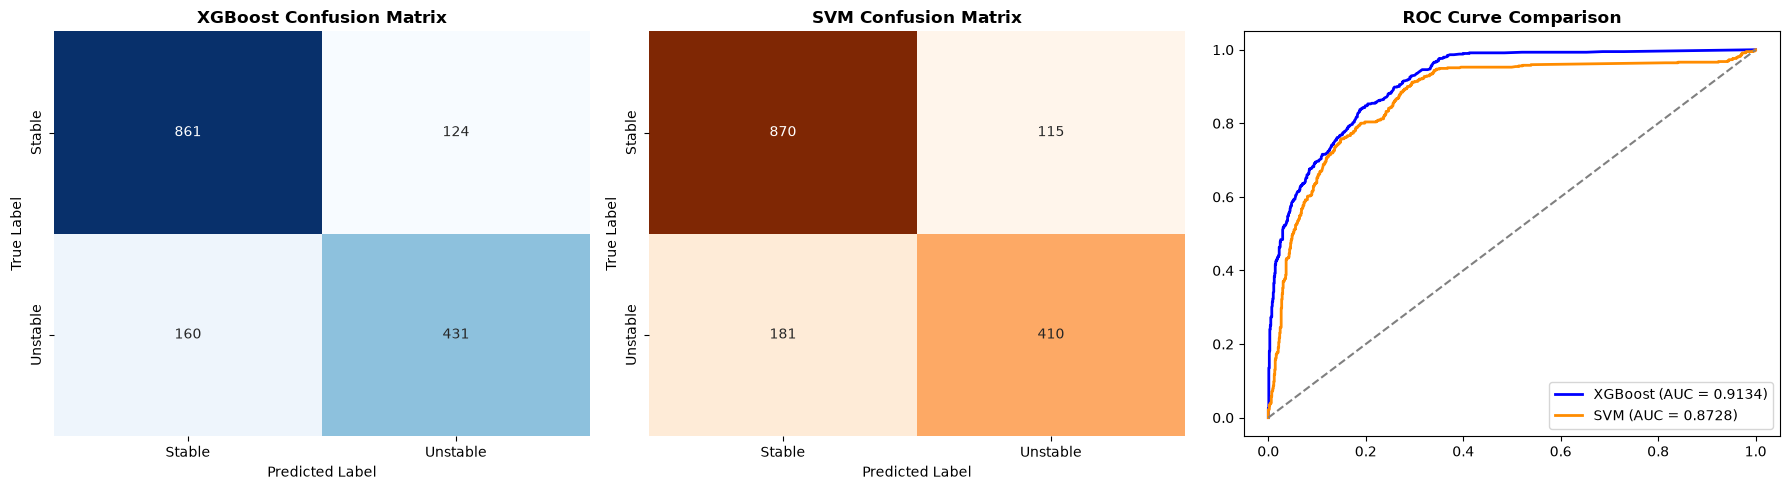

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc

fig, axes = plt.subplots(1, 3, figsize=(18, 5), dpi=100)

# Plot 1: XGBoost Confusion Matrix
cm_xgb = confusion_matrix(y_test, xgb_preds)
sns.heatmap(cm_xgb, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False, 
            xticklabels=['Stable', 'Unstable'], yticklabels=['Stable', 'Unstable'])
axes[0].set_title('XGBoost Confusion Matrix', fontweight='bold')
axes[0].set_ylabel('True Label')
axes[0].set_xlabel('Predicted Label')

# Plot 2: SVM Confusion Matrix
cm_svm = confusion_matrix(y_test, svm_preds)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Oranges', ax=axes[1], cbar=False,
            xticklabels=['Stable', 'Unstable'], yticklabels=['Stable', 'Unstable'])
axes[1].set_title('SVM Confusion Matrix', fontweight='bold')
axes[1].set_ylabel('True Label')
axes[1].set_xlabel('Predicted Label')

# Plot 3: ROC Curve Comparison
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, xgb_probs)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_probs)
axes[2].plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC = {auc(fpr_xgb, tpr_xgb):.4f})', color='blue', lw=2)
axes[2].plot(fpr_svm, tpr_svm, label=f'SVM (AUC = {auc(fpr_svm, tpr_svm):.4f})', color='darkorange', lw=2)
axes[2].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[2].set_title('ROC Curve Comparison', fontweight='bold')
axes[2].legend(loc="lower right")

plt.tight_layout()
plt.show()

## 💾 Step 6: Model Serialization
We export both models, along with the `StandardScaler` needed for the SVM inference pathway.

In [6]:
import joblib
import os

os.makedirs('MachineLearning/models', exist_ok=True)
joblib.dump(scaler, 'MachineLearning/models/input_scaler.joblib')
joblib.dump(xgb_model, 'MachineLearning/models/xgboost_risk_model.joblib')
joblib.dump(svm_model, 'MachineLearning/models/svm_risk_model.joblib')
joblib.dump(feature_cols, 'MachineLearning/models/feature_columns.joblib')
print("Exported input_scaler, xgboost, svm, and feature_columns to /models/")

Exported input_scaler, xgboost, svm, and feature_columns to /models/
